In [ ]:
# Cell 1
!pip -q install requests networkx pyvis python-louvain

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 61.2 MB/s eta 0:00:00


In [ ]:
# Cell 2
import pandas as pd
import numpy as np

import requests
import networkx as nx

import matplotlib.pyplot as plt

In [ ]:
from google.colab import files

uploaded = files.upload()

In [ ]:
import os

print(os.listdir("/content"))

['.config', 'Consensus_Biomarkers.csv', 'Top20_DEGs.csv', 'Significant_DEGs.csv', 'TCGA_BRCA_expression_processed.csv', 'clinical_matched.csv', 'expression_filtered.csv', 'significant_genes.csv', 'DEG_results.csv', 'sample_data']


In [ ]:
import pandas as pd

consensus = pd.read_csv(
    "Consensus_Biomarkers.csv",
    index_col=0
)

consensus.head()

,Random Forest,ExtraTrees,XGBoost,CatBoost,Models Supporting
CA12,True,False,True,True,3
FOXC1,False,True,True,True,3
FOXA1,True,True,True,False,3
ESR1,True,False,True,True,3
DNALI1,True,True,False,False,2


In [ ]:
gene_list = consensus.index.tolist()

print(f"Number of consensus biomarkers: {len(gene_list)}")
print(gene_list)

Number of consensus biomarkers: 64
['CA12', 'FOXC1', 'FOXA1', 'ESR1', 'DNALI1', 'B3GNT5', 'GATA3', 'HAPLN3', 'TBC1D9', 'UGT8', 'PRR15', 'WNT6', 'C17orf28', 'C1QL2', 'C6orf211', 'AR', 'CD300LG', 'CACNA2D2', 'C8orf46', 'C6orf97', 'C1orf64', 'DEGS2', 'CKS2', 'COX7B', 'ERBB2', 'DZIP1', 'DACH1', 'ABCC8', 'ARSG', 'BBS1', 'BPI', 'AGR2', 'GABRP', 'FSIP1', 'FAM171A1', 'FAM48A', 'ESYT3', 'IFRD1', 'GRB7', 'GPR160', 'LCT', 'LEMD1', 'MYB', 'MICALL1', 'PPP1R14C', 'INPP4B', 'KRT83', 'HPDL', 'RND1', 'RASGEF1C', 'RABEP1', 'ROPN1', 'SOX10', 'SPDEF', 'SDR42E1', 'S100B', 'TMEM217', 'STAC', 'VGLL1', 'TTYH1', 'VPS37B', 'XBP1', 'ZMYND10', 'ZNF839']


In [ ]:
import requests
import pandas as pd

genes = "%0d".join(gene_list)

url = "https://string-db.org/api/tsv/network"

params = {
    "identifiers": genes,
    "species": 9606,
    "required_score": 400,
    "caller_identity": "TNBC_Project"
}

response = requests.post(url, data=params)

print(response.status_code)

200


In [ ]:
from io import StringIO

ppi = pd.read_csv(
    StringIO(response.text),
    sep="\t"
)

ppi.head()

,stringId_A,stringId_B,preferredName_A,preferredName_B,ncbiTaxonId,score,nscore,fscore,pscore,ascore,escore,dscore,tscore
0,9606.ENSP00000178638,9606.ENSP00000405330,CA12,ESR1,9606,0.403,0,0.0,0,0.067,0.041,0.0,0.387
1,9606.ENSP00000184183,9606.ENSP00000380093,ROPN1,SOX10,9606,0.420,0,0.0,0,0.389,0.000,0.0,0.091
2,9606.ENSP00000216037,9606.ENSP00000368632,XBP1,GATA3,9606,0.462,0,0.0,0,0.067,0.000,0.0,0.447
3,9606.ENSP00000216037,9606.ENSP00000391490,XBP1,AGR2,9606,0.463,0,0.0,0,0.086,0.000,0.0,0.437
4,9606.ENSP00000216037,9606.ENSP00000250448,XBP1,FOXA1,9606,0.499,0,0.0,0,0.083,0.000,0.0,0.476


In [ ]:
ppi.to_csv(
    "STRING_Interactions.csv",
    index=False
)

print("STRING interaction table saved successfully!")

STRING interaction table saved successfully!


In [ ]:
print(f"Number of interactions: {len(ppi)}")

print(f"Number of unique proteins: {len(set(ppi['preferredName_A']).union(set(ppi['preferredName_B'])))}")

Number of interactions: 49
Number of unique proteins: 27


In [ ]:
# Build the protein-protein interaction network

G = nx.from_pandas_edgelist(
    ppi,
    source="preferredName_A",
    target="preferredName_B",
    edge_attr="score"
)

print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

Number of nodes: 27
Number of edges: 49


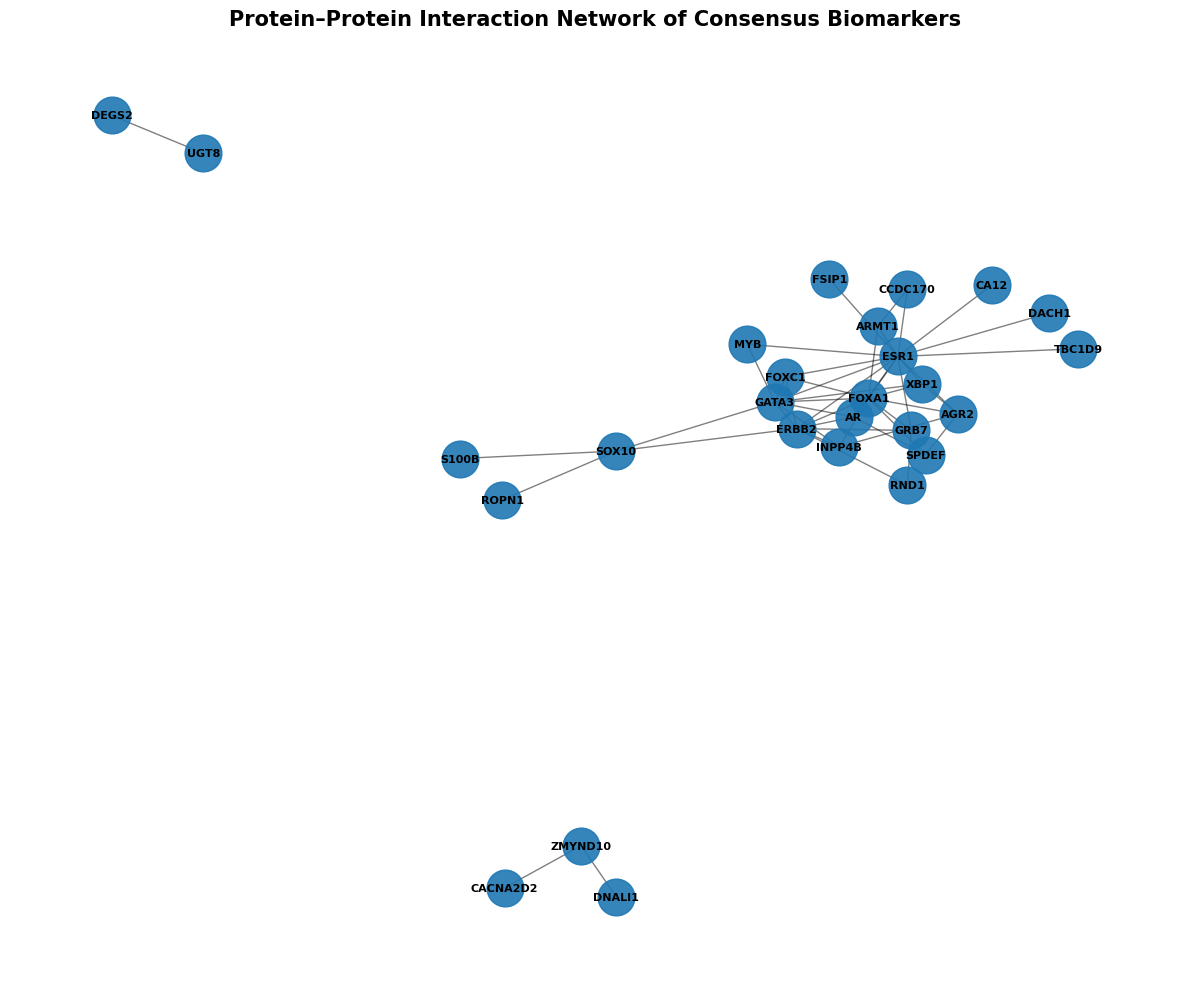

In [ ]:
plt.figure(figsize=(12,10))

pos = nx.spring_layout(G, seed=42)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=700,
    alpha=0.9
)

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.5
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=8,
    font_weight="bold"
)

plt.title(
    "Protein–Protein Interaction Network of Consensus Biomarkers",
    fontsize=15,
    fontweight="bold"
)

plt.axis("off")

plt.tight_layout()

plt.savefig(
    "Figure12_PPI_Network.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

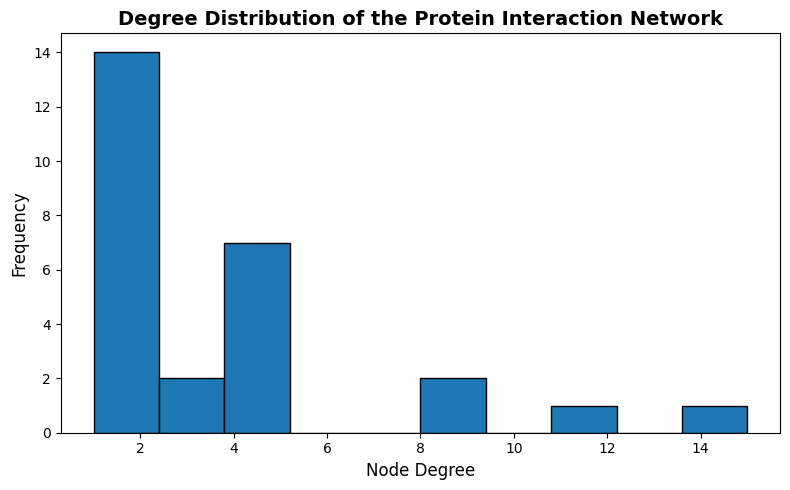

In [ ]:
degrees = [degree for node, degree in G.degree()]

plt.figure(figsize=(8,5))

plt.hist(
    degrees,
    bins=10,
    edgecolor="black"
)

plt.xlabel("Node Degree", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.title(
    "Degree Distribution of the Protein Interaction Network",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "Figure13_Degree_Distribution.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
components = list(nx.connected_components(G))

print("Number of connected components:", len(components))

largest_component = max(components, key=len)

print("Size of largest component:", len(largest_component))

Number of connected components: 3
Size of largest component: 22


In [ ]:
density = nx.density(G)

print(f"Network Density: {density:.4f}")

Network Density: 0.1396


In [ ]:
nx.write_gml(
    G,
    "TNBC_PPI_Network.gml"
)

print("Network exported successfully.")

Network exported successfully.
